In [1]:
# Importar librerías
import pandas as pd
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Cargar el archivo
file_path = 'E:/Bootcamp/customer/Mall_Customers.csv'
data = pd.read_csv(file_path)

# Mostrar las primeras filas del dataset
data.head()


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


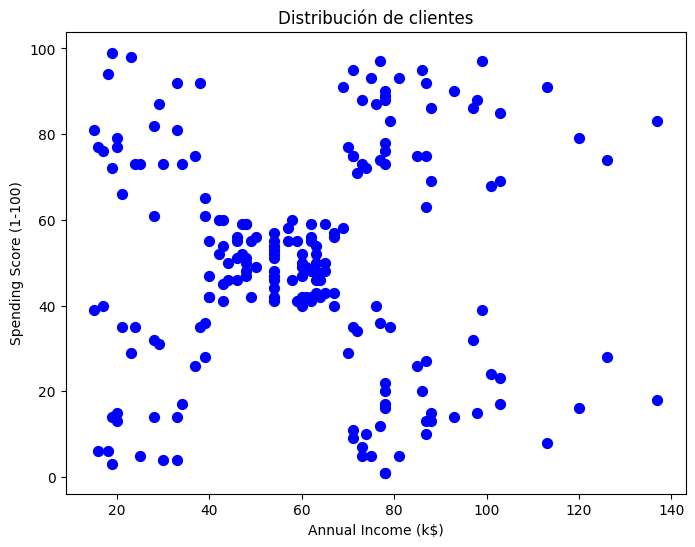

In [2]:
# Selección de las variables relevantes
data_selected = data[['Annual Income (k$)', 'Spending Score (1-100)']]

# Visualización inicial de los datos seleccionados
plt.figure(figsize=(8, 6))
plt.scatter(data_selected['Annual Income (k$)'], data_selected['Spending Score (1-100)'], c='blue', s=50)
plt.title("Distribución de clientes")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.show()


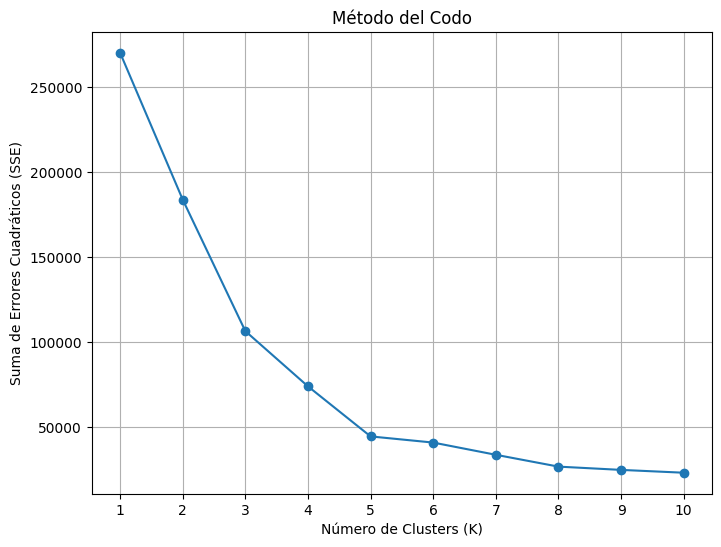

In [3]:
# Método del codo para determinar el número óptimo de clusters
sse = []  # Suma de errores cuadráticos

# Probar diferentes valores de K
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(data_selected)
    sse.append(kmeans.inertia_)

# Visualización del método del codo
plt.figure(figsize=(8, 6))
plt.plot(range(1, 11), sse, marker='o')
plt.title("Método del Codo")
plt.xlabel("Número de Clusters (K)")
plt.ylabel("Suma de Errores Cuadráticos (SSE)")
plt.xticks(range(1, 11))
plt.grid(True)
plt.show()


C:\Users\chave\AppData\Local\Temp\ipykernel_17544\1214730406.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_selected['Cluster'] = clusters


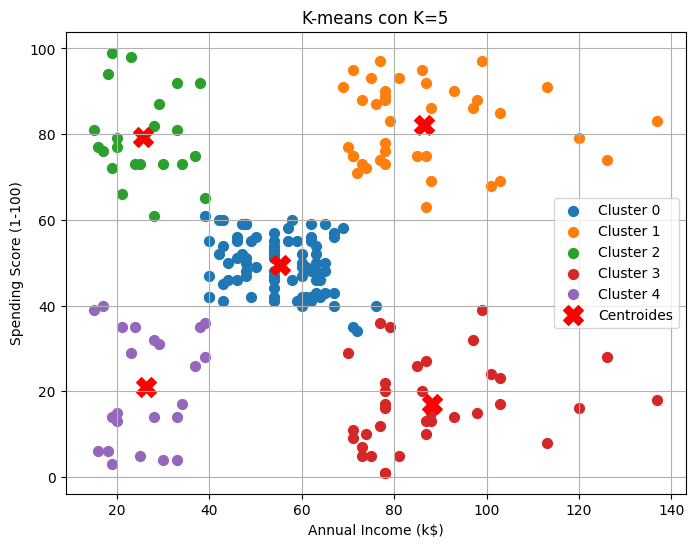

In [4]:
# Elegir el número de clusters
k = 5

# Aplicar el algoritmo K-means
kmeans = KMeans(n_clusters=k, random_state=42)
clusters = kmeans.fit_predict(data_selected)

# Agregar los clusters al DataFrame original
data_selected['Cluster'] = clusters

# Visualización de los clusters
plt.figure(figsize=(8, 6))
for cluster in range(k):
    cluster_data = data_selected[data_selected['Cluster'] == cluster]
    plt.scatter(cluster_data['Annual Income (k$)'], 
                cluster_data['Spending Score (1-100)'], 
                label=f'Cluster {cluster}', s=50)
    
# Visualizar los centroides
centroids = kmeans.cluster_centers_
plt.scatter(centroids[:, 0], centroids[:, 1], c='red', marker='X', s=200, label='Centroides')
    
plt.title(f"K-means con K={k}")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.legend()
plt.grid(True)
plt.show()
